# Notebook 03 — K-means Clustering

Notebook này phân cụm khách hàng bằng **K-means** trên không gian RFM.

**Quy trình:**
1. Tiền xử lý: `log1p` + `StandardScaler`
2. Tìm số cụm tối ưu: **Elbow Method** + **Silhouette Score**
3. Fit K-means với k tối ưu
4. Gán nhãn phân khúc kinh doanh
5. Xuất kết quả

**Đầu vào:** `data/processed/rfm_table.csv`  
**Đầu ra:** `data/processed/rfm_segments.csv`

## 1. Setup

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from src.models.calculators.rfm_calculator import RFMCalculator
from src.models.kmeans_segmentor import KMeansSegmentor

RFM_PATH      = '../data/processed/rfm_table.csv'
SEGMENTS_PATH = '../data/processed/rfm_segments.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Đọc RFM Table

In [2]:
rfm = pd.read_csv(RFM_PATH)
print(f'Số khách hàng: {len(rfm):,}')
display(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head())
display(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Số khách hàng: 3,920


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,209,32448.84
3,12749,4,5,4090.88
4,12820,3,4,942.34


,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00
mean,92.21,4.25,1849.64
std,99.53,7.20,7470.34
min,1.00,1.00,3.75
25%,18.00,1.00,295.26
50%,51.00,2.00,638.06
75%,143.00,5.00,1562.58
max,374.00,209.00,259657.30


## 3. Tiền xử lý features

K-means nhạy cảm với scale và outliers. Pipeline tiền xử lý gồm 2 bước:
1. **`log1p`** — giảm độ lệch phải
2. **`StandardScaler`** — đưa các features về cùng thang đo (mean=0, std=1)

In [3]:
from sklearn.preprocessing import StandardScaler

X = rfm[['Recency', 'Frequency', 'Monetary']].values
X_scaled = StandardScaler().fit_transform(np.log1p(X))

print('Features sau tiền xử lý (5 dòng đầu):')
print(pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary']).head().round(3))

Features sau tiền xử lý (5 dòng đầu):
   Recency  Frequency  Monetary
0    1.464     -0.958     3.790
1   -2.036      1.669     1.452
2   -2.338      5.865     3.094
3   -1.655      0.653     1.432
4   -1.821      0.386     0.254


## 4. Tìm số cụm tối ưu

### 4.1 Elbow Method

Vẽ **inertia** (tổng bình phương khoảng cách trong cụm) theo k.  
Chọn k tại điểm "khuỷu tay" — nơi inertia giảm chậm lại đáng kể.

In [4]:
segmentor = KMeansSegmentor(random_state=42)
k_range = range(2, 11)

results = segmentor.find_optimal_k(X, k_range=k_range)
print('K\tInertia\t\tSilhouette')
for k, ine, sil in zip(results['k_range'], results['inertias'], results['silhouette_scores']):
    print(f'{k}\t{ine:,.1f}\t\t{sil:.4f}')

K	Inertia		Silhouette
2	5,814.6		0.4353
3	4,341.9		0.3413
4	3,506.0		0.3384
5	2,933.8		0.3187
6	2,533.7		0.3156
7	2,256.5		0.3115
8	2,063.5		0.3073
9	1,899.0		0.2840
10	1,760.8		0.2808


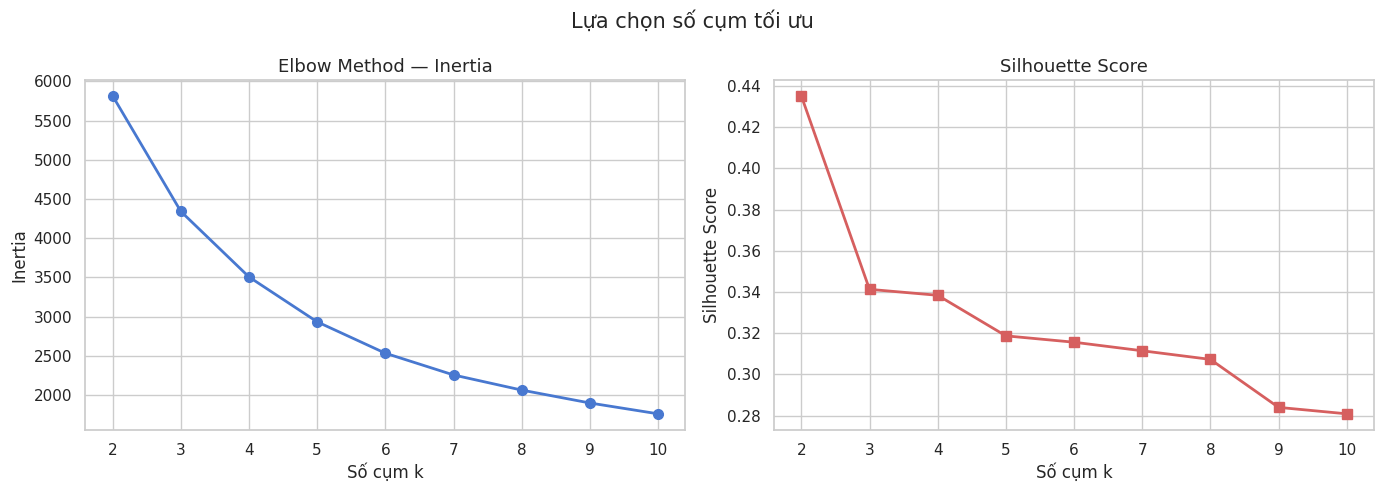

K có Silhouette cao nhất: 2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(results['k_range'], results['inertias'], 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia', fontsize=13)
axes[0].set_xlabel('Số cụm k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(results['k_range'])

# Silhouette
axes[1].plot(results['k_range'], results['silhouette_scores'], 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('Số cụm k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(results['k_range'])

plt.suptitle('Lựa chọn số cụm tối ưu', fontsize=15)
plt.tight_layout()
plt.show()

best_k_sil = results['k_range'][results['silhouette_scores'].index(max(results['silhouette_scores']))]
print(f'K có Silhouette cao nhất: {best_k_sil}')

### 4.2 Chọn k

Dựa vào Elbow + Silhouette, chọn `K_OPTIMAL`.  
Trong dự án này thường ra k = 4.

In [6]:
K_OPTIMAL = 4   # Thay đổi nếu biểu đồ gợi ý k khác

## 5. Fit K-means

In [7]:
segmentor.fit(X, n_clusters=K_OPTIMAL)
labels = segmentor.predict(X)

print(f'Phân bố cụm (k={K_OPTIMAL}):')
cluster_counts = pd.Series(labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f'  Cluster {cluster}: {count:,} khách hàng ({count/len(labels)*100:.1f}%)')

Phân bố cụm (k=4):
  Cluster 0: 1,432 khách hàng (36.5%)
  Cluster 1: 643 khách hàng (16.4%)
  Cluster 2: 1,061 khách hàng (27.1%)
  Cluster 3: 784 khách hàng (20.0%)


## 6. Gán nhãn phân khúc

In [8]:
rfm_seg = segmentor.assign_segment_labels(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']], labels)

print('Phân bố theo Segment:')
display(rfm_seg['Segment'].value_counts().to_frame('Count'))

Phân bố theo Segment:


,Count
Segment,
At Risk,1432
Loyal Customers,1061
Potential Loyalists,784
Champions,643


## 7. Phân tích từng cụm

### 7.1 Trung bình R, F, M theo cụm

In [9]:
profile = (
    rfm_seg.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
    .mean()
    .round(1)
    .sort_values('Monetary', ascending=False)
)
profile['Count'] = rfm_seg.groupby('Segment')['CustomerID'].count()
print('Hồ sơ trung bình từng phân khúc:')
display(profile)

Hồ sơ trung bình từng phân khúc:


,Recency,Frequency,Monetary,Count
Segment,,,,
Champions,11.7,13.6,7130.6,643
Loyal Customers,69.3,4.2,1701.6,1061
Potential Loyalists,19.7,2.1,507.0,784
At Risk,185.0,1.3,323.1,1432


### 7.2 Scatter plots: R vs F, F vs M, R vs M

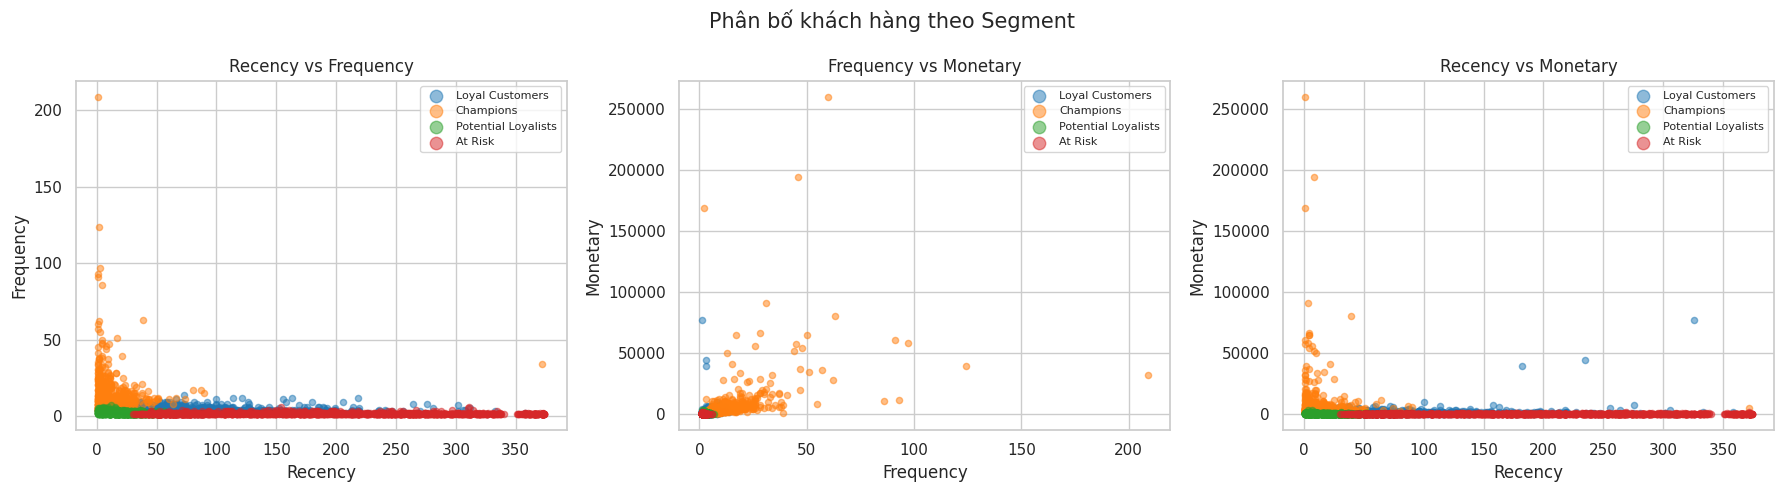

In [10]:
segments = rfm_seg['Segment'].unique()
palette = dict(zip(segments, sns.color_palette('tab10', n_colors=len(segments))))

pairs = [('Recency', 'Frequency'), ('Frequency', 'Monetary'), ('Recency', 'Monetary')]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    for seg in segments:
        mask = rfm_seg['Segment'] == seg
        ax.scatter(
            rfm_seg.loc[mask, x_col],
            rfm_seg.loc[mask, y_col],
            label=seg, alpha=0.5, s=20, color=palette[seg]
        )
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('Phân bố khách hàng theo Segment', fontsize=15)
plt.tight_layout()
plt.show()

### 7.3 Box plots R, F, M theo Segment

/tmp/ipykernel_58415/2469089570.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58415/2469089570.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58415/2469089570.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


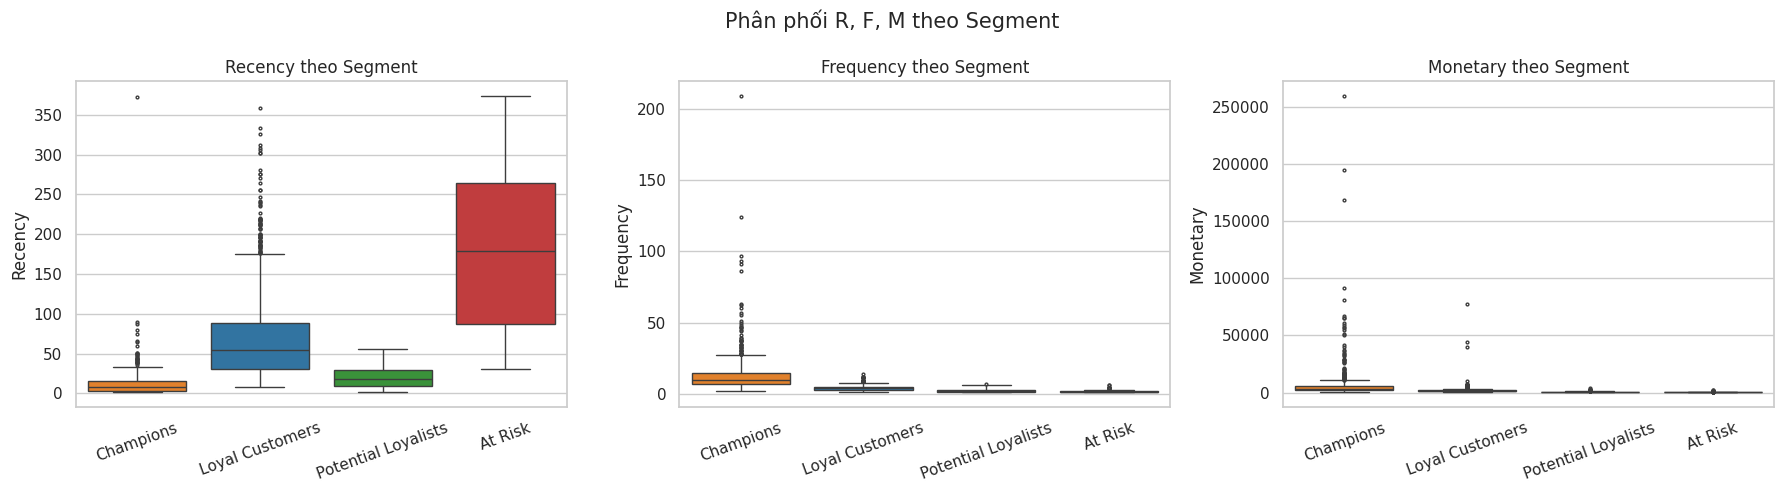

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Recency', 'Frequency', 'Monetary']

for ax, metric in zip(axes, metrics):
    order = profile.index.tolist()
    sns.boxplot(
        data=rfm_seg, x='Segment', y=metric, order=order,
        palette=palette, ax=ax, fliersize=2
    )
    ax.set_title(f'{metric} theo Segment')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Phân phối R, F, M theo Segment', fontsize=15)
plt.tight_layout()
plt.show()

### 7.4 Radar chart — hồ sơ cụm

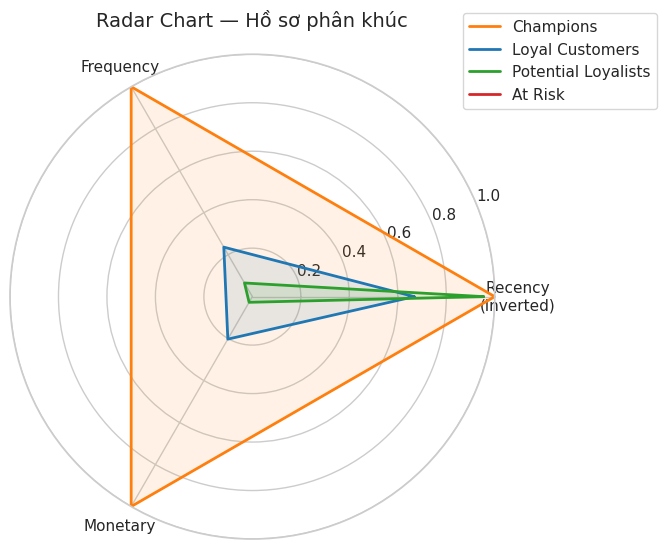

In [12]:
from sklearn.preprocessing import MinMaxScaler

radar_data = profile[['Recency', 'Frequency', 'Monetary']].copy()
# Invert Recency so higher = better for all axes
radar_data['Recency'] = radar_data['Recency'].max() - radar_data['Recency']
radar_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(radar_data),
    index=radar_data.index, columns=radar_data.columns
)

categories = ['Recency\n(inverted)', 'Frequency', 'Monetary']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for seg in radar_norm.index:
    values = radar_norm.loc[seg].tolist()
    values += values[:1]
    ax.plot(angles, values, label=seg, linewidth=2, color=palette.get(seg))
    ax.fill(angles, values, alpha=0.1, color=palette.get(seg))

ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Hồ sơ phân khúc', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## 8. Diễn giải & chiến lược marketing

| Phân khúc | Đặc điểm | Chiến lược gợi ý |
|---|---|---|
| **Champions** | Mua gần đây, thường xuyên, chi tiêu cao | Reward, upsell, ambassador program |
| **Loyal Customers** | Mua thường xuyên, chi tiêu tốt | Loyalty program, early access |
| **Potential Loyalists** | Mới mua, tiềm năng tăng trưởng | Onboarding, cross-sell, nurture |
| **At Risk** | Từng mua nhiều nhưng gần đây không quay lại | Win-back campaign, ưu đãi hấp dẫn |
| **Lost Customers** | Không mua từ rất lâu, tần suất thấp | Reactivation email, khảo sát lý do |


## 9. Xuất kết quả

In [13]:
rfm_full = rfm.merge(rfm_seg[['CustomerID', 'Cluster', 'Segment']], on='CustomerID')
rfm_full.to_csv(SEGMENTS_PATH, index=False)

print(f'Đã lưu kết quả phân cụm tại: {SEGMENTS_PATH}')
print(f'Kích thước: {rfm_full.shape[0]:,} khách hàng x {rfm_full.shape[1]} cột')
print(f'Cột: {list(rfm_full.columns)}')
display(rfm_full.head())

Đã lưu kết quả phân cụm tại: ../data/processed/rfm_segments.csv
Kích thước: 3,920 khách hàng x 10 cột
Cột: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Cluster', 'Segment']


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
0,12346,326,1,77183.60,1,1,5,7,2,Loyal Customers
1,12747,2,11,4196.01,5,4,5,14,1,Champions
2,12748,1,209,32448.84,5,4,5,14,1,Champions
3,12749,4,5,4090.88,5,3,5,13,1,Champions
4,12820,3,4,942.34,5,3,4,12,3,Potential Loyalists
